# DMD & Camera Control
Ajile DMD 4500 + Alkeria CELERA camera via `alkusb3`.

## 1. Imports

In [4]:
import alkusb3
from alkusb3 import celera_camera, feature, trigger_source
import sys
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import ajiledriver as aj
from scipy.stats import norm

## 2. DMD Control

In [42]:
class AjileController:
    def __init__(self, ip="192.168.10.130", port=5005, project_name="Project"):
        self.ip_address     = ip
        self.netmask        = "255.255.255.0"
        self.gateway        = "0.0.0.0"
        self.port           = port
        self.comm_interface = aj.USB3_INTERFACE_TYPE
        self.device_number  = 0
        self.project_name   = project_name
        self.repeat_count   = 0    # 0 = infinite
        self.frame_time_ms  = 100
        self.sequence_id    = 1
        self.system         = None

    def connect(self):
        self.system = aj.HostSystem()
        self.system.SetConnectionSettingsStr(self.ip_address, self.netmask, self.gateway, self.port)
        self.system.SetCommunicationInterface(self.comm_interface)
        self.system.SetUSB3DeviceNumber(self.device_number)
        if self.system.StartSystem() != aj.ERROR_NONE:
            print(f"CRITICAL: Failed to connect to Ajile device at {self.ip_address}")
            sys.exit(-1)
        print(f"Connected to Ajile device: {self.ip_address}")

    def start(self, create_project_fn, image_array):
        """Load project and start DMD sequence — returns immediately so camera can capture."""
        project = create_project_fn(
            sequenceID=self.sequence_id,
            sequenceRepeatCount=self.repeat_count,
            frameTime_ms=self.frame_time_ms,
            components=self.system.GetProject().Components(),
            projectname=self.project_name,
            image_ar=image_array,
        )
        _, found = project.FindSequence(self.sequence_id)
        if not found:
            sys.exit(-1)

        comp_idx = self.system.GetProject().GetComponentIndexWithDeviceType(aj.DMD_4500_DEVICE_TYPE)
        driver   = self.system.GetDriver()

        driver.StopSequence(comp_idx)
        driver.LoadProject(project)
        driver.WaitForLoadComplete(-1)

        for _, sequence in project.Sequences().iteritems():
            roi_w = sequence.SequenceItems()[0].Frames()[0].RoiWidthColumns()
            if 0 < roi_w < aj.DMD_3000_IMAGE_WIDTH_MAX:
                driver.SetLiteMode(True, comp_idx)

            driver.StartSequence(sequence.ID(), comp_idx)
            while self.system.GetDeviceState(comp_idx).RunState() != aj.RUN_STATE_RUNNING:
                time.sleep(0.01)

        print("DMD sequence running.")

    def stop(self):
        if self.system:
            comp_idx = self.system.GetProject().GetComponentIndexWithDeviceType(aj.DMD_4500_DEVICE_TYPE)
            self.system.GetDriver().StopSequence(comp_idx)
            print("DMD sequence stopped.")


def create_project(sequenceID=1, sequenceRepeatCount=0, frameTime_ms=100,
                   components=None, projectname="project", image_ar=None):
    if image_ar is None or len(image_ar) == 0:
        print("No image array provided.")
        sys.exit(-1)

    project = aj.Project(projectname)
    if components is not None:
        project.SetComponents(components)

    if len(project.Components()) == 0:
        print("No connected devices detected.")
        sys.exit(-1)

    if image_ar.shape[2] != aj.DMD_IMAGE_WIDTH_MAX or image_ar.shape[1] != aj.DMD_IMAGE_HEIGHT_MAX:
        print(f"Expected ({aj.DMD_IMAGE_WIDTH_MAX}, {aj.DMD_IMAGE_HEIGHT_MAX}), "
              f"got ({image_ar.shape[2]}, {image_ar.shape[1]}).")

    controller_idx, dmd_idx = None, None
    for i, comp in enumerate(project.Components()):
        hw = comp.DeviceType().HardwareType()
        if hw in {aj.AJILE_CONTROLLER_DEVICE_TYPE,
                  aj.AJILE_2PORT_CONTROLLER_DEVICE_TYPE,
                  aj.AJILE_3PORT_CONTROLLER_DEVICE_TYPE}:
            controller_idx = i
        elif hw == aj.DMD_4500_DEVICE_TYPE:
            dmd_idx = i

    if controller_idx is None or dmd_idx is None:
        print("Controller or DMD component not found.")
        sys.exit(-1)

    in_trig  = project.Components()[controller_idx].InputTriggerSettings()
    out_trig = project.Components()[controller_idx].OutputTriggerSettings()
    for i in range(len(out_trig)):
        out_trig[i] = aj.ExternalTriggerSetting(aj.RISING_EDGE, 0)
    project.SetTriggerSettings(controller_idx, in_trig, out_trig)

    rule = aj.TriggerRule()
    rule.AddTriggerFromDevice(aj.TriggerRulePair(dmd_idx, aj.FRAME_STARTED))
    rule.SetTriggerToDevice(aj.TriggerRulePair(controller_idx, aj.EXT_TRIGGER_OUTPUT_1))
    project.AddTriggerRule(rule)

    for idx, img in enumerate(image_ar, start=1):
        image = aj.Image(idx)
    
        image.ReadFromMemory(img, 8, aj.ROW_MAJOR_ORDER, aj.DMD_4500_DEVICE_TYPE)
        project.AddImage(image)

    sequence = aj.Sequence(sequenceID, projectname, aj.DMD_4500_DEVICE_TYPE,
                           aj.SEQ_TYPE_PRELOAD, sequenceRepeatCount)
    project.AddSequence(sequence)
    project.AddSequenceItem(aj.SequenceItem(sequenceID, 1))

    for i in range(len(image_ar)):
        frame = aj.Frame()
        frame.SetSequenceID(sequenceID)
        frame.SetImageID(i + 1)
        frame.SetFrameTimeMSec(frameTime_ms)
        project.AddFrame(frame)

    return project

## 3. Camera Control (alkusb3 — Alkeria CELERA)

In [43]:
def list_cameras():
    """Print and return available CELERA camera IDs."""
    cam = celera_camera()
    ids = cam.get_camera_list()
    if not ids:
        print("No cameras found.")
    for i, cid in enumerate(ids):
        print(f"  [{i}] {cid}")
    return ids


class CameraController:
    def __init__(self, camera_index=0):
        self.camera_index = camera_index
        self._cam = None

    def connect(self):
        self._cam = celera_camera()
        ids = self._cam.get_camera_list()
        if not ids:
            raise RuntimeError("No CELERA cameras detected.")
        self._cam.camera = self.camera_index
        self._cam.init()
        print(f"Connected to camera [{self.camera_index}]: {ids[self.camera_index]}")

    def set_exposure(self, shutter_value):
        """Set shutter/exposure in camera units."""
        self._cam.set_feature_value(feature.shutter, shutter_value)

    def set_gain(self, gain_value):
        """Set analog gain."""
        self._cam.set_feature_value(feature.gain, gain_value)

    def set_roi(self, width, height, start_x=0, start_y=0):
        self._cam.image_size_x  = width
        self._cam.image_size_y  = height
        self._cam.image_start_x = start_x
        self._cam.image_start_y = start_y

    def set_frame_rate(self, fps):
        self._cam.frame_rate = fps

    def start(self):
        self._cam.acquire = True

    def stop_acquisition(self):
        self._cam.acquire = False

    def capture_frame(self):
        """Capture one frame, return as numpy array."""
        buf = self._cam.get_image_ptr(sync=True)
        if buf is None:
            raise RuntimeError("Frame capture timed out.")
        arr = buf.as_numpy_array(copy=True)
        buf.dispose()
        return arr

    def capture_frames(self, n_frames):
        """Capture n_frames frames, return as list of numpy arrays."""
        return [self.capture_frame() for _ in range(n_frames)]

    def capture_frames_triggered(self, n_frames):
        """Capture n_frames in hardware-trigger mode (rising edge from DMD)."""
        trig = self._cam.frame_start_trigger
        trig.enabled                    = True
        trig.source                     = trigger_source.external
        trig.external_input             = 0
        trig.detect_external_input_edge = True
        trig.invert_external_input      = False
        frames = self.capture_frames(n_frames)
        trig.enabled = False
        return frames

    def show_frame(self, frame):
        plt.figure(figsize=(6, 5))
        plt.imshow(frame, cmap="gray")
        plt.colorbar()
        plt.axis("off")
        plt.show()

    def disconnect(self):
        if self._cam:
            self._cam.acquire = False
            self._cam.close()
            self._cam = None
            print("Camera disconnected.")

## 4. Pattern Generation

In [44]:
def dmd_upward_arrow(width, height, arrow_width, arrow_height):
    """
    Create an upward arrow pattern centered on the board.

    Parameters:
        width, height   : output image size
        arrow_width     : total arrow width
        arrow_height    : total arrow height

    Returns:
        board reshaped as (1, height, width, 1)
    """

    board = np.zeros((height, width), dtype=np.uint8)

    cx, cy = width // 2, height // 2

    # Arrow dimensions
    shaft_width = arrow_width // 3
    shaft_height = arrow_height // 2

    # Shaft coordinates
    shaft_x0 = cx - shaft_width // 2
    shaft_x1 = cx + shaft_width // 2
    shaft_y0 = cy
    shaft_y1 = cy + shaft_height

    # Draw shaft
    cv2.rectangle(board,
                  (shaft_x0, shaft_y0),
                  (shaft_x1, shaft_y1),
                  255, -1)

    # Triangle head points
    tip = (cx, cy - arrow_height // 2)
    left = (cx - arrow_width // 2, cy)
    right = (cx + arrow_width // 2, cy)

    pts = np.array([tip, left, right], np.int32)

    # Draw arrow head
    cv2.fillPoly(board, [pts], 255)

    return board.reshape(1, height, width, 1)

def dmd_chessboard(width, height, sq_width, sq_height, sub_sq):
    board = np.zeros((height, width), dtype=np.uint8)
    cx, cy = width // 2, height // 2
    x0, y0 = cx - sub_sq // 2, cy - sub_sq // 2
    x1, y1 = cx + sub_sq // 2, cy + sub_sq // 2
    for y in range(y0, y1, sq_height * 2):
        for x in range(x0, x1, sq_width * 2):
            cv2.rectangle(board, (x, y), (x + sq_width, y + sq_height), 255, -1)
            if x + sq_width < x1 and y + sq_height < y1:
                cv2.rectangle(board, (x + sq_width, y + sq_height),
                              (x + 2 * sq_width, y + 2 * sq_height), 255, -1)
    return board.reshape(1, height, width, 1)


def dmd_solid(width, height, value=255):
    """Full-screen solid pattern (all on / all off)."""
    return np.full((1, height, width, 1), value, dtype=np.uint8)


def dmd_square(width, height, sq_half, offset_x=0, offset_y=0):
    """Single centred square with optional pixel offset."""
    img = np.zeros((height, width), dtype=np.uint8)
    cx, cy = width // 2 - offset_x, height // 2 - offset_y
    cv2.rectangle(img, (cx - sq_half, cy - sq_half),
                       (cx + sq_half, cy + sq_half), 255, -1)
    return img.reshape(1, height, width, 1)


def dmd_random_binary(width, height, density, sq_width, sq_height,
                      n_frames, sub_sq, copy_num=1):
    """Random binary patterns with given pixel density inside sub_sq region."""
    cx, cy = width // 2, height // 2
    x0, y0 = cx - sub_sq // 2, cy - sub_sq // 2
    size_y  = int(np.ceil(sub_sq / sq_height))
    size_x  = int(np.ceil(sub_sq / sq_width))
    frames = []
    for _ in range(n_frames):
        img  = np.zeros((height, width), dtype=np.uint8)
        mask = (np.random.rand(size_y, size_x) < density) * 255
        for j in range(size_y):
            for i in range(size_x):
                cv2.rectangle(img,
                              (x0 + i * sq_width,       y0 + j * sq_height),
                              (x0 + (i + 1) * sq_width, y0 + (j + 1) * sq_height),
                              int(mask[j, i]), -1)
        frames.append(img)
    arr = np.stack(frames).reshape(n_frames, height, width, 1)
    return np.repeat(arr, copy_num, axis=0)

In [45]:
import os
import cv2
import numpy as np

def save_pattern_pair(input_pattern, output_pattern, idx, save_dir="dataset"):
    """
    Save input DMD pattern and corresponding output image.
    """

    input_dir = os.path.join(save_dir, "input")
    output_dir = os.path.join(save_dir, "output")

    os.makedirs(input_dir, exist_ok=True)
    os.makedirs(output_dir, exist_ok=True)

    cv2.imwrite(
        os.path.join(input_dir, f"input_{idx:05d}.png"),
        input_pattern
    )

    cv2.imwrite(
        os.path.join(output_dir, f"output_{idx:05d}.png"),
        output_pattern
    )

In [54]:
patterns = dmd_random_binary(
    width= DMD_WIDTH,
    height=DMD_HEIGHT,
    density=0.5,
    sq_width=4,
    sq_height=4,
    n_frames=1000,
    sub_sq=512
)

# for i in range(patterns.shape[0]):

#     dmd_img = patterns[i, :, :, 0]

#     # Send to DMD
#     # dmd.display(dmd_img)

#     # Acquire image from camera
#     output_img = cam.capture_frame()

#     # Save pair
#     # save_pattern_pair(dmd_img, output_img, i)

In [55]:
import os
import numpy as np
from tqdm import tqdm

os.makedirs("inputs", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

for i in tqdm(range(patterns.shape[0])):

    dmd_img = patterns[i, :, :, 0]
    cam_img = cam.capture_frame()

    # save each matrix separately
    np.save(f"inputs/input_{i:05d}.npy", dmd_img)
    np.save(f"outputs/output_{i:05d}.npy", cam_img)


100%|██████████| 1000/1000 [01:18<00:00, 12.76it/s]


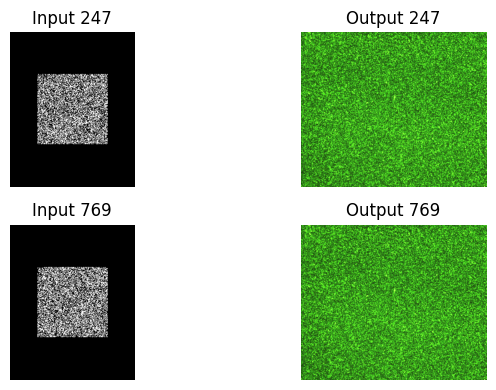

In [56]:
# inputs = tqdm(np.array(inputs, dtype=np.uint8))      #crash - very large
# outputs = tqdm(np.array(outputs, dtype=np.uint8))

import numpy as np
import matplotlib.pyplot as plt

num_examples = 2
indices = np.random.randint(0, 1000, size=num_examples)

fig, axes = plt.subplots(num_examples, 2, figsize=(8, 2 * num_examples))

for i, idx in enumerate(indices):

    inp = np.load(f"inputs/input_{idx:05d}.npy")
    out = np.load(f"outputs/output_{idx:05d}.npy")

    axes[i, 0].imshow(inp, cmap="gray")
    axes[i, 0].set_title(f"Input {idx}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(out, cmap="gray")
    axes[i, 1].set_title(f"Output {idx}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [20]:
# import os
# import cv2
# import numpy as np

# save_dir = "inputs"
# os.makedirs(save_dir, exist_ok=True)

# for i in range(len(inputs)):
#     img = inputs[i]

#     # Remove singleton dimensions if needed
#     img = np.squeeze(img)

#     cv2.imwrite(
#         os.path.join(save_dir, f"input_{i:05d}.png"),
#         img
#     )

# np.savez_compressed(
#     "dmd_dataset2.npz",
#     inputs=inputs,
#     # outputs=outputs
# )

In [ ]:
data = np.load("dmd_dataset.npz")

inputs = data["inputs"]
outputs = data["outputs"]

In [ ]:
def dmd_random_binary_fast(width, height, density,
                           sq_width, sq_height,
                           n_frames, sub_sq):

    cx, cy = width // 2, height // 2
    x0, y0 = cx - sub_sq // 2, cy - sub_sq // 2

    size_y = int(np.ceil(sub_sq / sq_height))
    size_x = int(np.ceil(sub_sq / sq_width))

    frames = np.zeros((n_frames, height, width), dtype=np.uint8)

    for k in range(n_frames):

        mask = (np.random.rand(size_y, size_x) < density).astype(np.uint8) * 255

        expanded = np.repeat(mask, sq_height, axis=0)
        expanded = np.repeat(expanded, sq_width, axis=1)

        expanded = expanded[:sub_sq, :sub_sq]

        frames[k,
               y0:y0+expanded.shape[0],
               x0:x0+expanded.shape[1]] = expanded

    return frames[..., np.newaxis]

## 5. Configuration

In [34]:
# DMD
DMD_IP        = "192.168.200.1"
DMD_PORT      = 5005
DMD_WIDTH     = 912   # aj.DMD_IMAGE_WIDTH_MAX
DMD_HEIGHT    = 1140  # aj.DMD_IMAGE_HEIGHT_MAX
FRAME_TIME_MS = 300
REPEAT_COUNT  = 0     # 0 = infinite
PROJECT_NAME  = "experiment"

# Camera
CAMERA_INDEX  = 0
SHUTTER       = 1600  # shutter units (check camera docs for range)
GAIN          = 100

## 6. Connect Devices

In [12]:
list_cameras()

  [0] CELERA1 CO5S-C s/n A5C627F2


['CELERA1 CO5S-C s/n A5C627F2']

In [13]:
dmd = AjileController(ip=DMD_IP, port=DMD_PORT, project_name=PROJECT_NAME)
dmd.frame_time_ms = FRAME_TIME_MS
dmd.repeat_count  = REPEAT_COUNT
dmd.connect()

Connected to Ajile device: 192.168.200.1


In [35]:
cam = CameraController(camera_index=CAMERA_INDEX)
cam.connect()
cam.set_exposure(SHUTTER)
cam.set_gain(GAIN)
cam.start()

Connected to camera [0]: CELERA1 CO5S-C s/n A5C627F2


## 7. Run Experiment

In [36]:
def dmd_upward_arrow(width, height, arrow_width, arrow_height):

    # Explicitly set BLACK background
    board = np.zeros((height, width), dtype=np.uint8)

    cx, cy = width // 2, height // 2

    # Shaft dimensions
    shaft_width = arrow_width // 3
    shaft_height = arrow_height // 2

    # Shaft coordinates
    shaft_x0 = cx - shaft_width // 2
    shaft_x1 = cx + shaft_width // 2
    shaft_y0 = cy
    shaft_y1 = cy + shaft_height

    # Draw WHITE shaft
    cv2.rectangle(
        board,
        (shaft_x0, shaft_y0),
        (shaft_x1, shaft_y1),
        255,
        -1
    )

    # Arrow head
    pts = np.array([
        (cx, cy - arrow_height // 2),      # tip
        (cx - arrow_width // 2, cy),       # left
        (cx + arrow_width // 2, cy)        # right
    ], np.int32)

    # Draw WHITE arrow head
    cv2.fillPoly(board, [pts], 255)

    return board.reshape(1, height, width, 1)

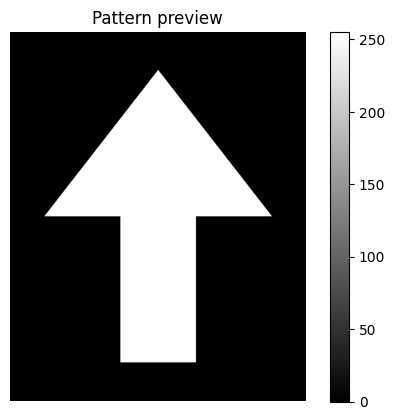

In [37]:
# Generate and preview pattern
# pattern = dmd_chessboard(DMD_WIDTH, DMD_HEIGHT, sq_width=180, sq_height=180, sub_sq=1000)
pattern = dmd_upward_arrow(
    width=DMD_WIDTH,
    height=DMD_HEIGHT,
    arrow_width=700,
    arrow_height=900
)

plt.imshow(pattern[0, :, :, 0], cmap="gray")
plt.title("Pattern preview")
plt.axis("off")
plt.colorbar()
plt.show()

In [27]:
# Start DMD — non-blocking, returns immediately
dmd.start(create_project, pattern)

DMD sequence running.


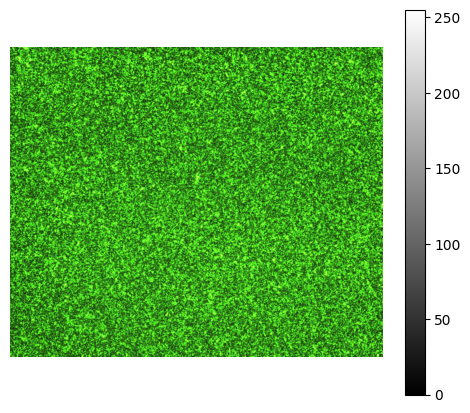

In [38]:
# Capture while pattern is live on DMD
img = cam.capture_frame()
cam.show_frame(img)

# Stop DMD after capture

In [13]:
# Capture multiple frames triggered by DMD (hardware sync via rising edge)
# dmd.start(create_project, pattern)
# triggered_frames = cam.capture_frames_triggered(n_frames=pattern.shape[0])
# dmd.stop()

## 8. Disconnect

In [14]:
cam.disconnect()
dmd.stop()

Camera disconnected.
DMD sequence stopped.
